In [1]:
# ============================================================
# Install dependencies
# ============================================================
!pip install sentence-transformers scikit-learn matplotlib seaborn pandas numpy scipy openpyxl -q

In [2]:
# ============================================================
# Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 150

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# ============================================================
# Upload the v3 raw response file (CSV)
# Expected file:  frontier_v3_raw_responses_*.csv
# Required columns: model, language, prompt_id, category, response
# Optional columns for cross-validation:
#   trans_border, identity, cultural_continuity, narrative, accuracy
# ============================================================
from google.colab import files
print("Please upload your frontier_v3_raw_responses_*.csv file:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"\nFile loaded: {filename}")

Please upload your frontier_v3_raw_responses_*.csv file:


Saving frontier_v3_raw_responses_20260128_042834.csv to frontier_v3_raw_responses_20260128_042834.csv

File loaded: frontier_v3_raw_responses_20260128_042834.csv


In [4]:
# ============================================================
# Load data and inspect
# ============================================================
df = pd.read_csv(filename)
print(f"Total responses: {len(df)}")
print(f"Models:    {df['model'].unique().tolist()}")
print(f"Languages: {df['language'].unique().tolist()}")
print(f"Prompts:   {sorted(df['prompt_id'].unique().tolist())}")
print(f"Columns:   {df.columns.tolist()}")
df.head()

Total responses: 44
Models:    ['GPT-5.1', 'DeepSeek-V3.2']
Languages: ['Chinese', 'English']
Prompts:   ['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'C1', 'C2', 'D1', 'D2', 'D3']
Columns:   ['prompt_id', 'category', 'model', 'model_origin', 'model_tier', 'language', 'prompt', 'response', 'timestamp']


,prompt_id,category,model,model_origin,model_tier,language,prompt,response,timestamp
0,A1,A,GPT-5.1,US,frontier,Chinese,傣族是什么？,傣族，简单说，是中国和东南亚地区一个以稻作文明和佛教文化著称的民族/民族共同体。\n\n重点...,2026-01-28T03:18:41.820028
1,A1,A,GPT-5.1,US,frontier,English,What are the Dai people?,The Dai are an ethnic group of Tai-speaking pe...,2026-01-28T03:18:50.807192
2,A1,A,DeepSeek-V3.2,China,frontier,Chinese,傣族是什么？,傣族是中国的一个少数民族，主要分布在云南省的西双版纳傣族自治州、德宏傣族景颇族自治州、临沧市...,2026-01-28T03:18:58.781777
3,A1,A,DeepSeek-V3.2,China,frontier,English,What are the Dai people?,The Dai people are one of the ethnic minority ...,2026-01-28T03:19:09.444001
4,A2,A,GPT-5.1,US,frontier,Chinese,傣语和泰语是什么关系？,简单说：傣语和泰语是“同一家族的近亲”，但不是同一种语言，更不能简单当成“方言关系”。\n\...,2026-01-28T03:19:39.803907


In [5]:
# ============================================================
# Feature engineering
# ============================================================

# Standardize language labels to EN / ZH
lang_map = {'English': 'EN', 'ZH': 'ZH', 'Chinese': 'ZH', 'english': 'EN', 'chinese': 'ZH'}
df['lang_short'] = df['language'].map(lang_map).fillna(df['language'])

# Create model-language group label, e.g. "GPT-5.1-EN"
df['group'] = df['model'] + '-' + df['lang_short']

# Map single-letter category codes to readable names
category_map = {'A': 'Factual', 'B': 'Cultural', 'C': 'Identity', 'D': 'Narrative'}
df['category_name'] = df['category'].map(category_map).fillna(df['category'])

print("Group distribution:")
print(df['group'].value_counts().to_string())
print("\nCategory distribution:")
print(df['category_name'].value_counts().to_string())

# Detect score columns (used later for cross-validation)
SCORE_COLS = [c for c in ['trans_border', 'identity', 'cultural_continuity', 'narrative', 'accuracy'] if c in df.columns]
HAS_SCORES = len(SCORE_COLS) > 0
print(f"\nManual score columns detected: {SCORE_COLS if HAS_SCORES else 'None — cross-validation will require a second upload'}")

Group distribution:
group
GPT-5.1-ZH          11
GPT-5.1-EN          11
DeepSeek-V3.2-ZH    11
DeepSeek-V3.2-EN    11

Category distribution:
category_name
Factual      12
Cultural     12
Narrative    12
Identity      8

Manual score columns detected: None — cross-validation will require a second upload


In [6]:
# ============================================================
# Load multilingual sentence-embedding model
# First run downloads ~120 MB; subsequent runs use cache
# ============================================================
print("Loading multilingual embedding model (first run may take ~1-2 min)...")
embed_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("Model ready: paraphrase-multilingual-MiniLM-L12-v2")
print("Embedding dimension: 384")

Loading multilingual embedding model (first run may take ~1-2 min)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model ready: paraphrase-multilingual-MiniLM-L12-v2
Embedding dimension: 384


In [7]:
# ============================================================
# Generate sentence embeddings for all responses
# ============================================================
print("Encoding responses...")
embeddings = embed_model.encode(df['response'].fillna('').tolist(), show_progress_bar=True)

print(f"\nEmbedding matrix shape: {embeddings.shape}")
print(f"({embeddings.shape[0]} responses x {embeddings.shape[1]} dimensions)")

Encoding responses...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


Embedding matrix shape: (44, 384)
(44 responses x 384 dimensions)


Running t-SNE dimensionality reduction...


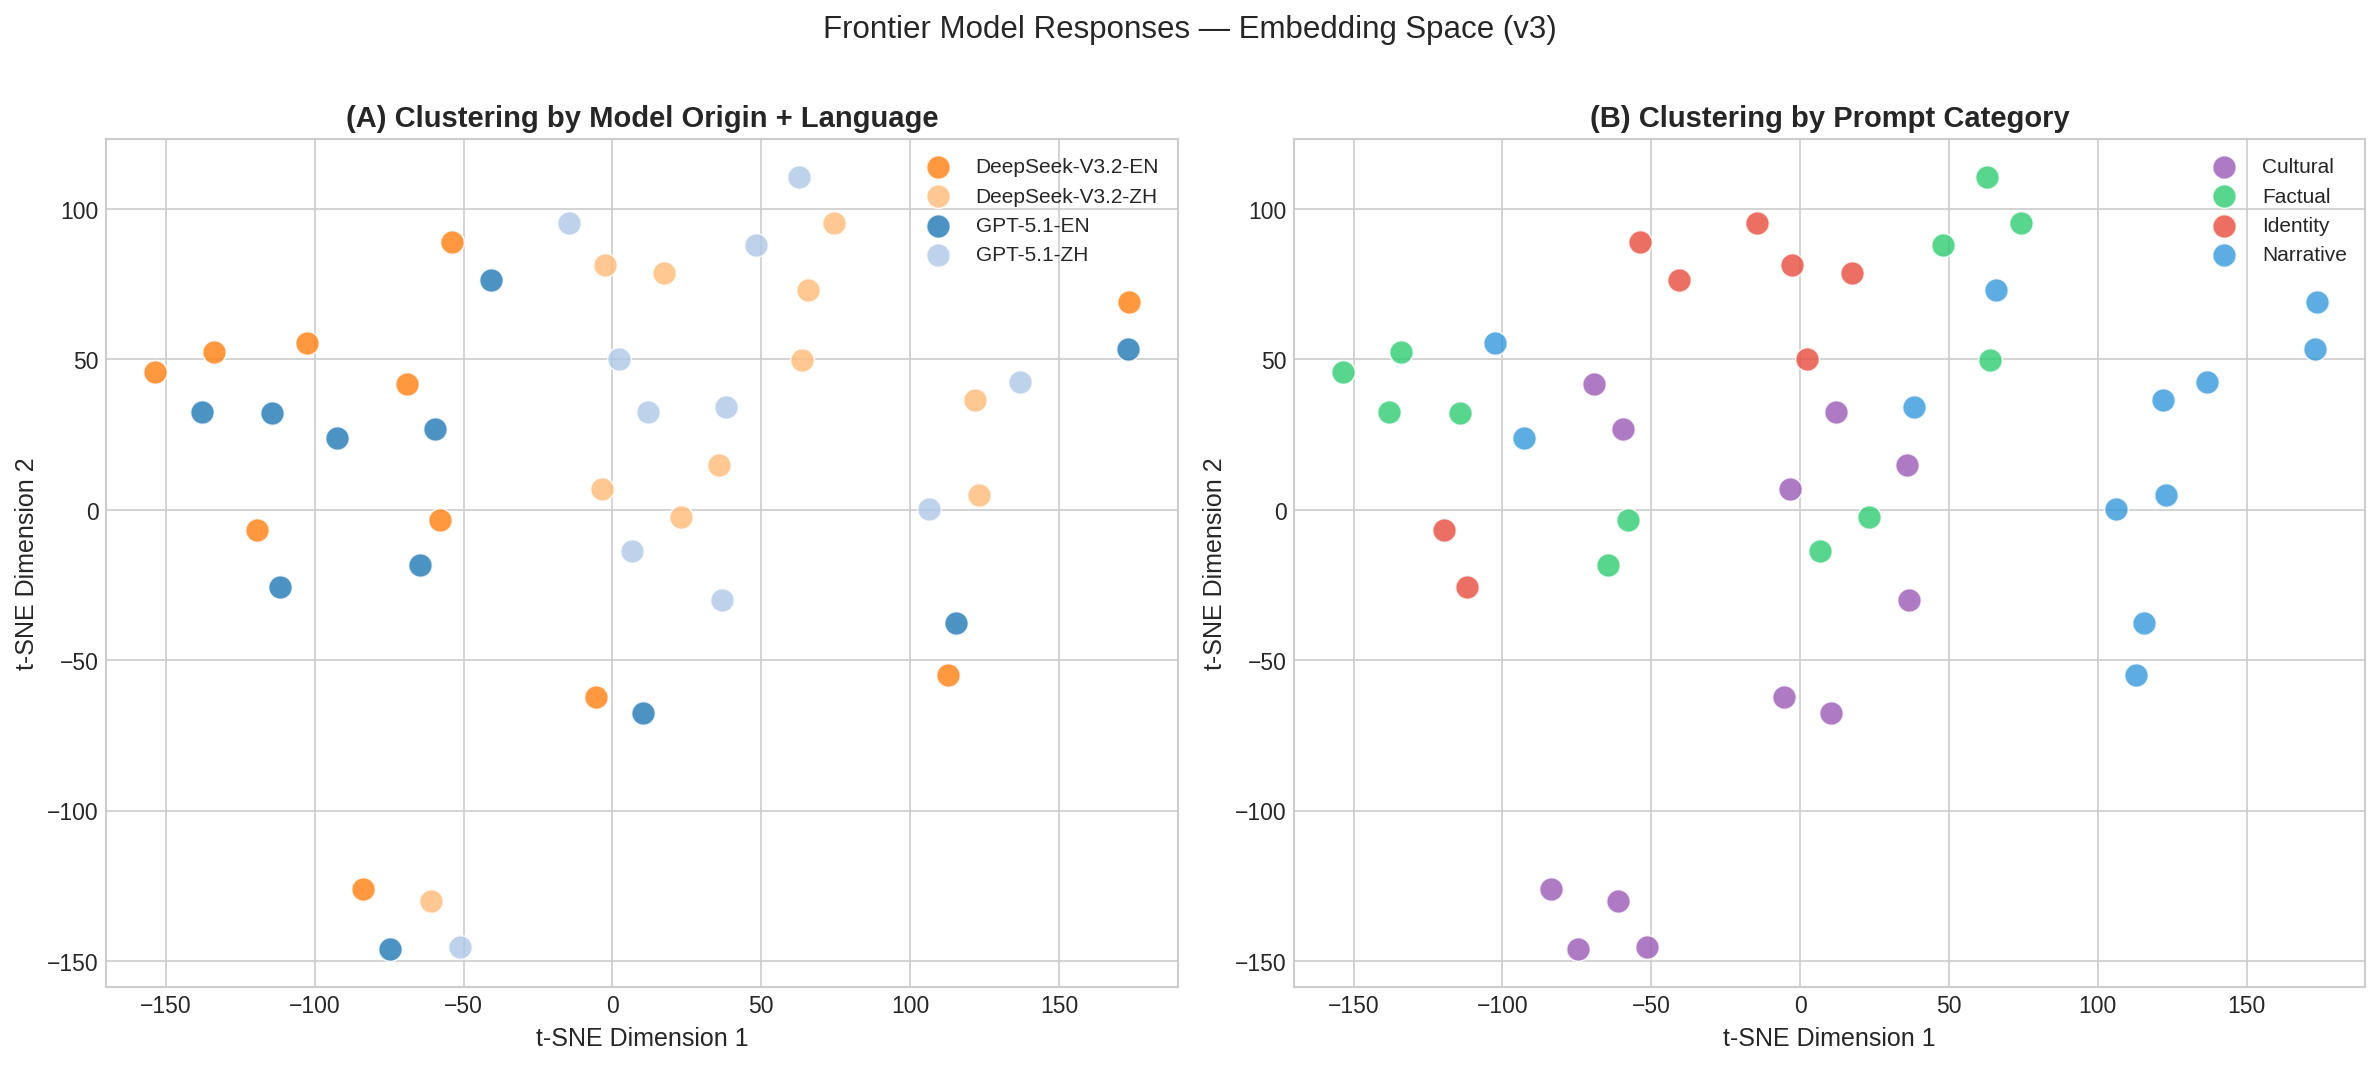

Saved: frontier_figure1_tsne_clusters.png


In [8]:
# ============================================================
# FIGURE 1  t-SNE Clustering
# Left panel:  colored by Model x Language group
# Right panel: colored by Prompt Category
# ============================================================
print("Running t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(10, len(df) - 1), n_iter=1500)
coords = tsne.fit_transform(embeddings)

df['tsne_x'] = coords[:, 0]
df['tsne_y'] = coords[:, 1]

# --- Color palettes ---
group_colors = {
    'GPT-5.1-EN':       '#1f77b4',   # Blue
    'GPT-5.1-ZH':       '#aec7e8',   # Light blue
    'DeepSeek-V3.2-EN': '#ff7f0e',   # Orange
    'DeepSeek-V3.2-ZH': '#ffbb78',   # Light orange
}
cat_colors = {
    'Factual':   '#2ecc71',
    'Cultural':  '#9b59b6',
    'Identity':  '#e74c3c',
    'Narrative': '#3498db',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Panel A: by model-language group ---
for grp in sorted(df['group'].unique()):
    mask = df['group'] == grp
    ax1.scatter(df.loc[mask, 'tsne_x'], df.loc[mask, 'tsne_y'],
                label=grp, c=group_colors.get(grp, 'gray'),
                s=130, alpha=0.8, edgecolors='white', linewidth=0.8)

ax1.set_title('(A) Clustering by Model Origin + Language', fontweight='bold', fontsize=14)
ax1.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax1.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax1.legend(loc='best', fontsize=10)

# --- Panel B: by prompt category ---
for cat in sorted(df['category_name'].unique()):
    mask = df['category_name'] == cat
    ax2.scatter(df.loc[mask, 'tsne_x'], df.loc[mask, 'tsne_y'],
                label=cat, c=cat_colors.get(cat, 'gray'),
                s=130, alpha=0.8, edgecolors='white', linewidth=0.8)

ax2.set_title('(B) Clustering by Prompt Category', fontweight='bold', fontsize=14)
ax2.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax2.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax2.legend(loc='best', fontsize=10)

plt.suptitle('Frontier Model Responses — Embedding Space (v3)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('frontier_figure1_tsne_clusters.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Saved: frontier_figure1_tsne_clusters.png")

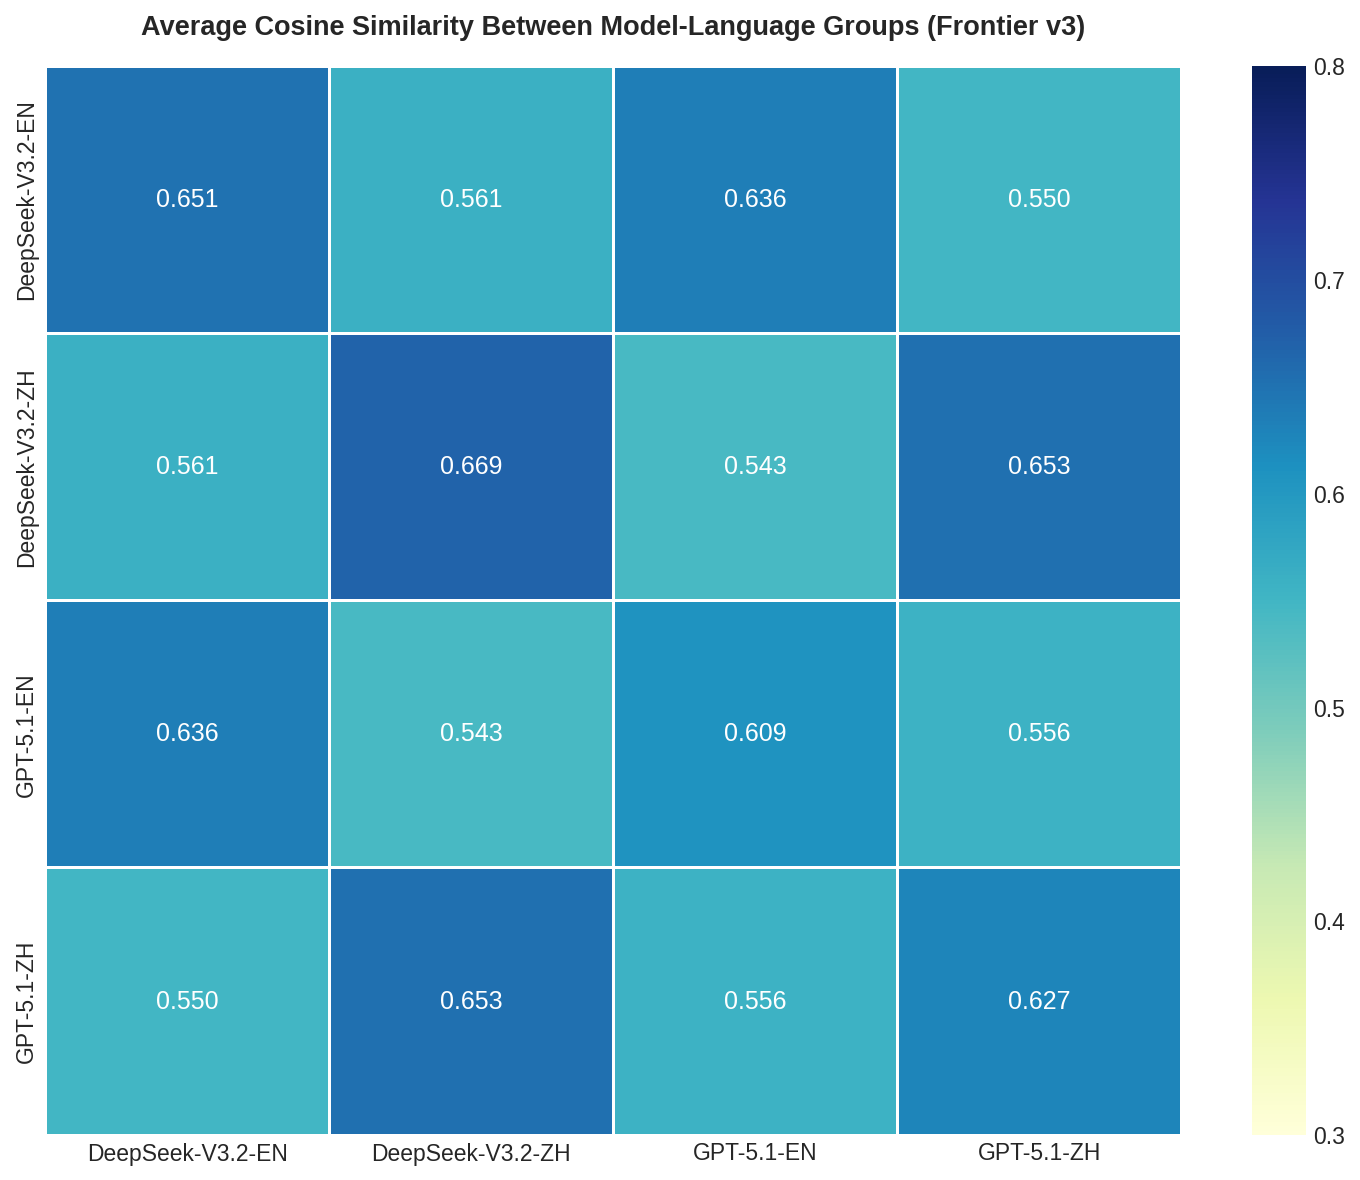

Saved: frontier_figure2_similarity_heatmap.png


In [9]:
# ============================================================
# FIGURE 2  Group-level cosine similarity heatmap
# ============================================================
groups = sorted(df['group'].unique())
n_groups = len(groups)

# Build n x n average similarity matrix
sim_matrix = np.zeros((n_groups, n_groups))
for i, g1 in enumerate(groups):
    for j, g2 in enumerate(groups):
        emb1 = embeddings[df['group'] == g1]
        emb2 = embeddings[df['group'] == g2]
        if i == j:
            # Intra-group: exclude self-similarity (diagonal of the sub-matrix)
            sub = cosine_similarity(emb1, emb2)
            n = sub.shape[0]
            sim_matrix[i, j] = (sub.sum() - n) / (n * n - n) if n > 1 else 1.0
        else:
            sim_matrix[i, j] = cosine_similarity(emb1, emb2).mean()

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix,
            xticklabels=groups, yticklabels=groups,
            annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0.3, vmax=0.8, linewidths=0.5,
            annot_kws={'size': 12})
plt.title('Average Cosine Similarity Between Model-Language Groups (Frontier v3)',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('frontier_figure2_similarity_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Saved: frontier_figure2_similarity_heatmap.png")

In [10]:
# ============================================================
# Key metric: Language effect vs. Model-origin effect
# Replicates the v2.1 analytical logic for direct comparison
# ============================================================
same_lang_diff_model = []   # EN-EN or ZH-ZH across different models
same_model_diff_lang = []   # Same model, EN vs ZH

for i, g1 in enumerate(groups):
    for j, g2 in enumerate(groups):
        if i < j:
            # Parse out model name and language suffix
            m1, l1 = g1.rsplit('-', 1)
            m2, l2 = g2.rsplit('-', 1)
            if l1 == l2 and m1 != m2:
                same_lang_diff_model.append(sim_matrix[i, j])
            elif m1 == m2 and l1 != l2:
                same_model_diff_lang.append(sim_matrix[i, j])

avg_same_lang  = np.mean(same_lang_diff_model)
avg_same_model = np.mean(same_model_diff_lang)

print("=" * 60)
print("KEY FINDING: Language Effect vs. Model-Origin Effect")
print("=" * 60)
print(f"  Same language, different model similarity : {avg_same_lang:.3f}")
print(f"  Same model,  different language similarity: {avg_same_model:.3f}")
print(f"  Difference (language dominance score)     : {avg_same_lang - avg_same_model:.3f}")

if avg_same_lang > avg_same_model:
    print("\n  ➜  LANGUAGE is the dominant clustering factor.")
    print("     Query language shapes representation more than model training origin.")
else:
    print("\n  ➜  MODEL ORIGIN is the dominant clustering factor.")
    print("     Training geography creates representational styles that persist across languages.")

KEY FINDING: Language Effect vs. Model-Origin Effect
  Same language, different model similarity : 0.644
  Same model,  different language similarity: 0.559
  Difference (language dominance score)     : 0.086

  ➜  LANGUAGE is the dominant clustering factor.
     Query language shapes representation more than model training origin.


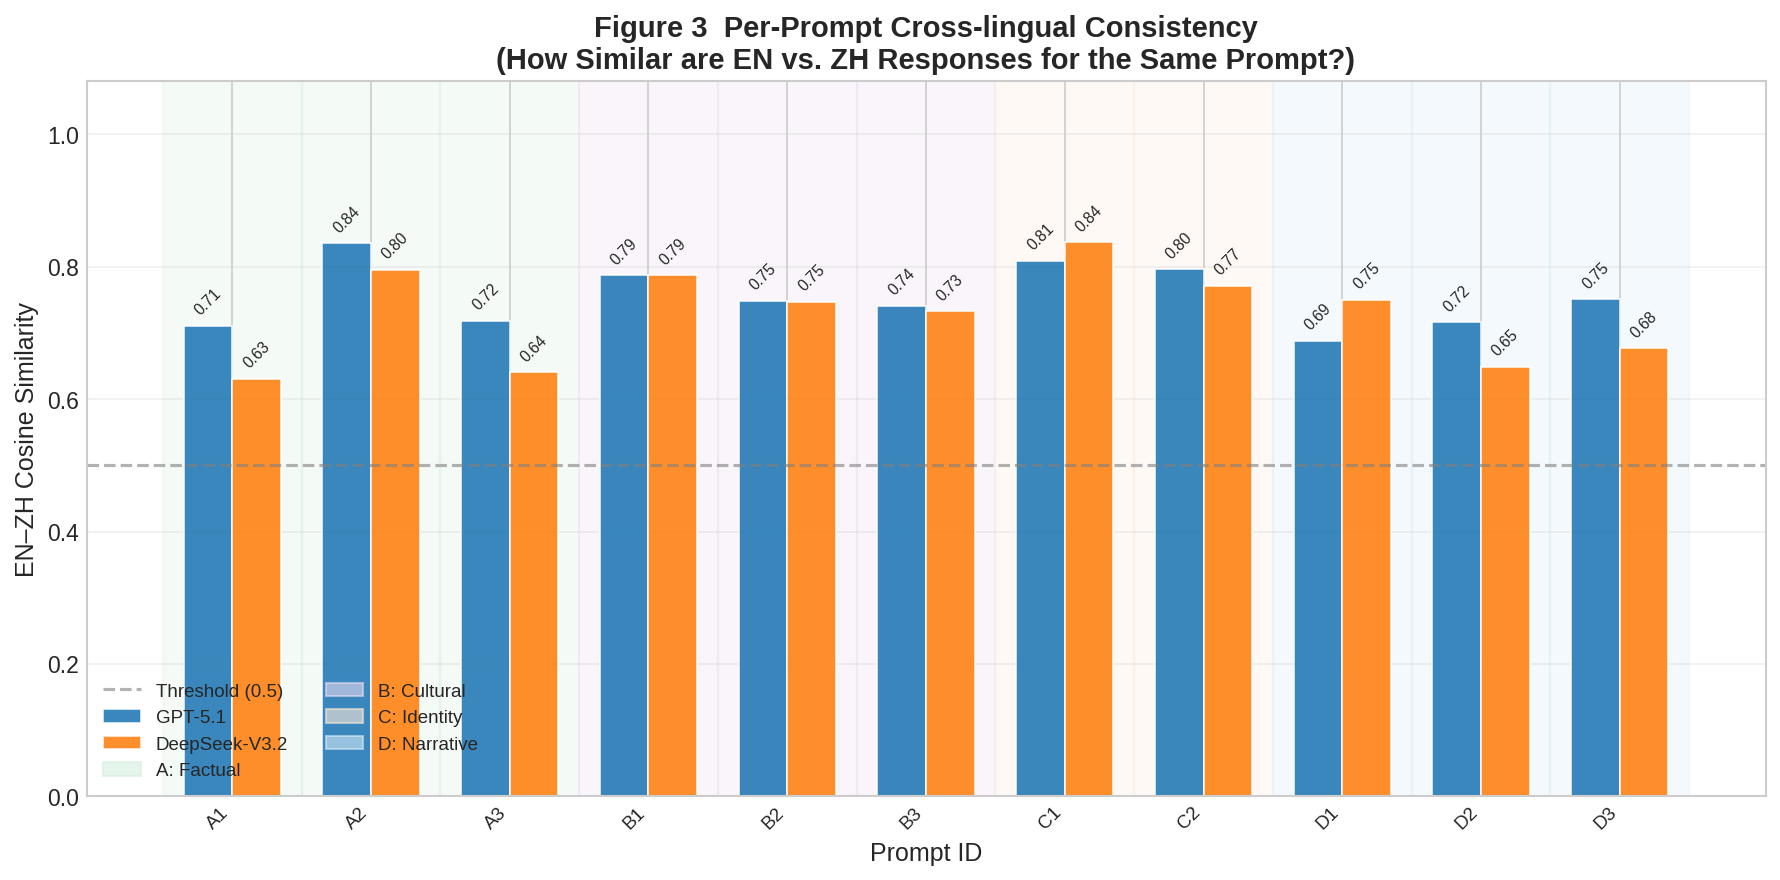

Saved: frontier_figure3_per_prompt_consistency.png

Per-prompt EN–ZH similarity table:
model      DeepSeek-V3.2  GPT-5.1  difference (GPT-DeepSeek)
prompt_id                                                   
A1                 0.630    0.711                      0.080
A2                 0.795    0.835                      0.040
A3                 0.641    0.718                      0.077
B1                 0.787    0.787                     -0.000
B2                 0.747    0.748                      0.002
B3                 0.733    0.741                      0.008
C1                 0.837    0.809                     -0.028
C2                 0.771    0.796                      0.025
D1                 0.750    0.688                     -0.061
D2                 0.649    0.716                      0.067
D3                 0.677    0.751                      0.074


In [11]:
# ============================================================
# FIGURE 3  Per-prompt EN–ZH cross-lingual consistency
#
# Each prompt gets a grouped bar showing EN vs ZH cosine
# similarity for GPT-5.1 and DeepSeek-V3.2 separately.
# Low similarity  → the model tells a different story depending
#                   on which language was used to ask.
# ============================================================

model_names  = ['GPT-5.1', 'DeepSeek-V3.2']
prompt_ids   = sorted(df['prompt_id'].unique())
model_colors_bar = {'GPT-5.1': '#1f77b4', 'DeepSeek-V3.2': '#ff7f0e'}

# Collect per-prompt, per-model EN–ZH similarity scores
per_prompt_results = []
for m in model_names:
    for pid in prompt_ids:
        en_mask = (df['group'] == f'{m}-EN') & (df['prompt_id'] == pid)
        zh_mask = (df['group'] == f'{m}-ZH') & (df['prompt_id'] == pid)
        if en_mask.sum() > 0 and zh_mask.sum() > 0:
            en_idx = df[en_mask].index[0]
            zh_idx = df[zh_mask].index[0]
            sim = cosine_similarity([embeddings[en_idx]], [embeddings[zh_idx]])[0][0]
            per_prompt_results.append({'model': m, 'prompt_id': pid, 'en_zh_sim': sim})

ppr_df = pd.DataFrame(per_prompt_results)

# --- Draw the chart ---
x     = np.arange(len(prompt_ids))
width = 0.35

fig, ax = plt.subplots(figsize=(max(12, len(prompt_ids) * 0.9), 6))

for k, m in enumerate(model_names):
    sims = [
        ppr_df[(ppr_df['model'] == m) & (ppr_df['prompt_id'] == pid)]['en_zh_sim'].values[0]
        if len(ppr_df[(ppr_df['model'] == m) & (ppr_df['prompt_id'] == pid)]) > 0 else np.nan
        for pid in prompt_ids
    ]
    offset = (k - 0.5) * width
    bars = ax.bar(x + offset, sims, width,
                  label=m, color=model_colors_bar[m],
                  edgecolor='white', linewidth=0.8, alpha=0.88)
    # Annotate bar tops
    for bar, val in zip(bars, sims):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.012,
                    f'{val:.2f}', ha='center', va='bottom',
                    fontsize=7.5, rotation=45)

# Reference line: 0.5 = moderate alignment threshold
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.6, label='Threshold (0.5)')

# Shade prompt categories for visual reference
cat_bg = {'A': '#d4efdf', 'B': '#e8daef', 'C': '#fde8d8', 'D': '#d6eaf8'}
prev_cat = None
for xi, pid in enumerate(prompt_ids):
    cat_code = str(pid)[0] if isinstance(pid, str) else None
    if cat_code in cat_bg:
        ax.axvspan(xi - 0.5, xi + 0.5, color=cat_bg[cat_code], alpha=0.25, zorder=0)

# Category legend patches
cat_patches = [
    mpatches.Patch(color=cat_bg['A'], alpha=0.6, label='A: Factual'),
    mpatches.Patch(color=cat_bg['B'], alpha=0.6, label='B: Cultural'),
    mpatches.Patch(color=cat_bg['C'], alpha=0.6, label='C: Identity'),
    mpatches.Patch(color=cat_bg['D'], alpha=0.6, label='D: Narrative'),
]

ax.set_xticks(x)
ax.set_xticklabels(prompt_ids, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Prompt ID', fontsize=12)
ax.set_ylabel('EN–ZH Cosine Similarity', fontsize=12)
ax.set_ylim(0, 1.08)
ax.set_title('Figure 3  Per-Prompt Cross-lingual Consistency\n'
             '(How Similar are EN vs. ZH Responses for the Same Prompt?)',
             fontweight='bold', fontsize=14)

# Combine both legend groups
handles1, labels1 = ax.get_legend_handles_labels()
ax.legend(handles=handles1 + cat_patches,
          loc='lower left', fontsize=9, ncol=2, framealpha=0.9)

ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('frontier_figure3_per_prompt_consistency.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Saved: frontier_figure3_per_prompt_consistency.png")

# Print per-prompt table
print("\nPer-prompt EN–ZH similarity table:")
pivot = ppr_df.pivot(index='prompt_id', columns='model', values='en_zh_sim')
pivot['difference (GPT-DeepSeek)'] = pivot.get('GPT-5.1', np.nan) - pivot.get('DeepSeek-V3.2', np.nan)
print(pivot.round(3).to_string())

In [12]:
# ============================================================
# CROSS-VALIDATION: Manual Coding Scores vs Embedding Similarity
#
# Research logic:
#   If embedding similarity genuinely reflects representational
#   content, then pairs of responses that are close in the
#   embedding space should also receive similar manual scores.
#   We test this by computing Pearson and Spearman correlations
#   between pairwise embedding similarity and pairwise manual
#   score difference for all within-prompt response pairs.
#
# Small code, large interpretive impact:
#   A significant negative correlation (r < 0, p < .05) confirms
#   that the embedding model tracks representational quality as
#   assessed by human coders — validating the automated analysis.
#   A near-zero or positive correlation would call into question
#   whether embeddings capture what manual coding captures.
# ============================================================

# --- Step 1: Obtain manual scores ---
# If score columns are already in the main CSV, use them directly.
# Otherwise upload a separate coded spreadsheet (Excel or CSV)
# that has the same prompt_id / model / language keys plus scores.

if not HAS_SCORES:
    print("No score columns found in the main file.")
    print("Please upload the manual coding file (xlsx or csv) with columns:")
    print("  prompt_id, model, language, trans_border, identity,")
    print("  cultural_continuity, narrative, accuracy")
    print()
    score_uploaded = files.upload()
    score_filename = list(score_uploaded.keys())[0]
    if score_filename.endswith('.xlsx'):
        score_df = pd.read_excel(score_filename)
    else:
        score_df = pd.read_csv(score_filename)

    # Standardize language labels in the score file
    if 'language' in score_df.columns:
        score_df['lang_short'] = score_df['language'].map(lang_map).fillna(score_df['language'])
    else:
        score_df['lang_short'] = score_df['lang_short']

    # Merge scores into df by matching prompt_id + model + language
    SCORE_COLS = [c for c in ['trans_border', 'identity', 'cultural_continuity', 'narrative', 'accuracy']
                 if c in score_df.columns]
    merge_keys = ['prompt_id', 'model', 'lang_short']
    df_scored = df.merge(score_df[merge_keys + SCORE_COLS], on=merge_keys, how='left')
    HAS_SCORES = True
else:
    # Scores already in the main df; nothing extra to load
    df_scored = df.copy()

print(f"Score columns in use: {SCORE_COLS}")
print(f"Rows with complete scores: {df_scored[SCORE_COLS].dropna().shape[0]} / {len(df_scored)}")

No score columns found in the main file.
Please upload the manual coding file (xlsx or csv) with columns:
  prompt_id, model, language, trans_border, identity,
  cultural_continuity, narrative, accuracy



Saving frontier_v3_manual_annotations.csv to frontier_v3_manual_annotations.csv
Score columns in use: ['trans_border', 'identity', 'cultural_continuity', 'narrative', 'accuracy']
Rows with complete scores: 44 / 44


Cross-validation pairs: 66


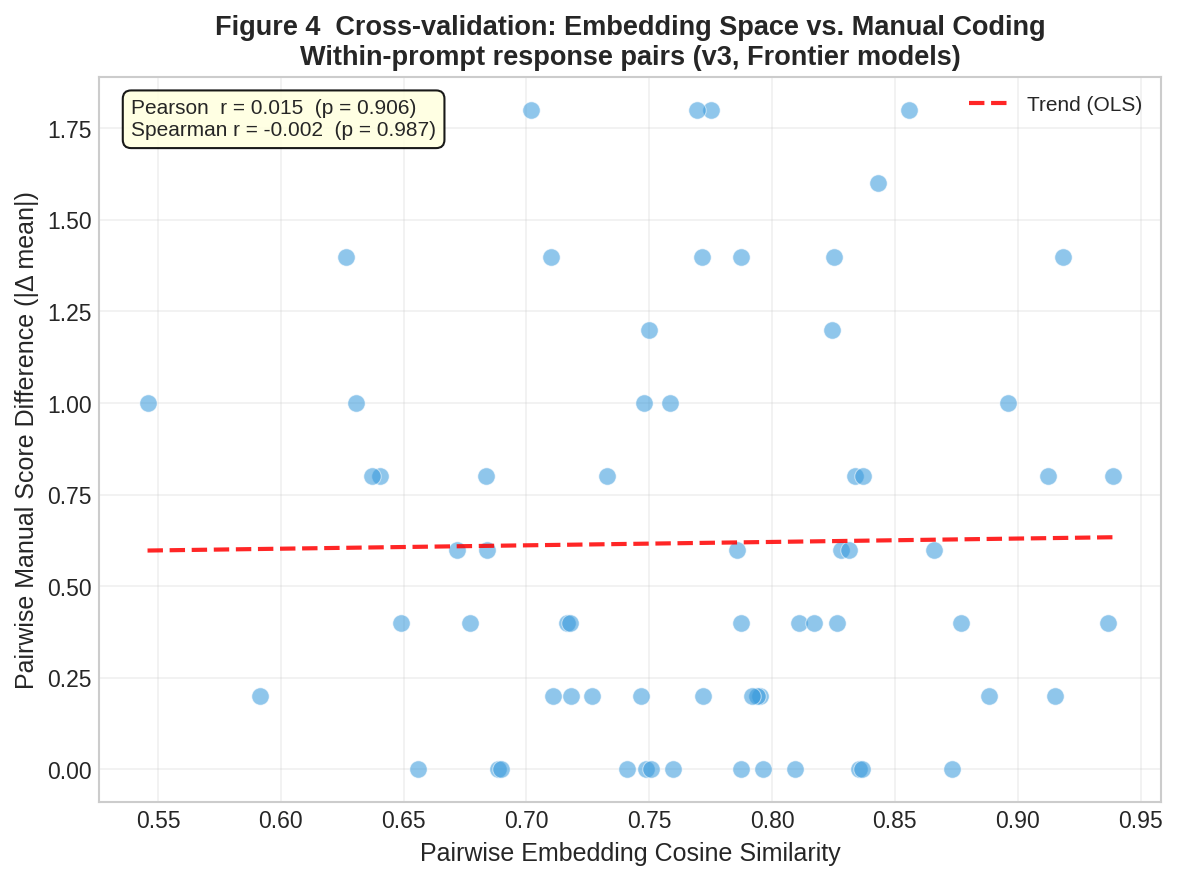

Saved: frontier_figure4_crossvalidation.png

CROSS-VALIDATION INTERPRETATION
WEAK / NO ALIGNMENT: Correlation is not significant (p >= .05).
  Embedding space may capture features (e.g. language, style)
  that differ from what manual codes measure.
  → Report as a LIMITATION; use both methods as complementary.


In [13]:
# ============================================================
# FIGURE 4  Embedding Similarity vs Manual Score Difference
#           (Cross-validation scatter + correlation)
# ============================================================

# Composite manual score: row mean across all available score cols
df_scored['mean_score'] = df_scored[SCORE_COLS].mean(axis=1)

# For every within-prompt pair of responses, record:
#   - their cosine similarity in embedding space
#   - the absolute difference in their composite manual score
xval_records = []
for pid in df_scored['prompt_id'].unique():
    idx_list = df_scored[df_scored['prompt_id'] == pid].index.tolist()
    for a in range(len(idx_list)):
        for b in range(a + 1, len(idx_list)):
            i, j = idx_list[a], idx_list[b]
            # Use the integer position in the original embeddings array
            pos_i = df_scored.index.get_loc(i)
            pos_j = df_scored.index.get_loc(j)
            emb_sim   = cosine_similarity([embeddings[pos_i]], [embeddings[pos_j]])[0][0]
            score_gap = abs(df_scored.loc[i, 'mean_score'] - df_scored.loc[j, 'mean_score'])
            if not np.isnan(score_gap):
                xval_records.append({'emb_sim': emb_sim, 'score_diff': score_gap})

xval_df = pd.DataFrame(xval_records)
print(f"Cross-validation pairs: {len(xval_df)}")

# Statistical tests
pearson_r, pearson_p  = pearsonr(xval_df['emb_sim'], xval_df['score_diff'])
spearman_r, spearman_p = spearmanr(xval_df['emb_sim'], xval_df['score_diff'])

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(xval_df['emb_sim'], xval_df['score_diff'],
           alpha=0.55, s=70, c='#3498db', edgecolors='white', linewidth=0.5)

# Regression trend line
z = np.polyfit(xval_df['emb_sim'], xval_df['score_diff'], 1)
x_line = np.linspace(xval_df['emb_sim'].min(), xval_df['emb_sim'].max(), 200)
ax.plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=2, alpha=0.85, label='Trend (OLS)')

# Annotation box
annotation = (
    f"Pearson  r = {pearson_r:.3f}  (p = {pearson_p:.3f})\n"
    f"Spearman r = {spearman_r:.3f}  (p = {spearman_p:.3f})"
)
ax.text(0.03, 0.97, annotation,
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9))

ax.set_xlabel('Pairwise Embedding Cosine Similarity', fontsize=12)
ax.set_ylabel('Pairwise Manual Score Difference (|Δ mean|)', fontsize=12)
ax.set_title('Figure 4  Cross-validation: Embedding Space vs. Manual Coding\n'
             'Within-prompt response pairs (v3, Frontier models)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('frontier_figure4_crossvalidation.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Saved: frontier_figure4_crossvalidation.png")

# --- Interpretation ---
print("\n" + "=" * 60)
print("CROSS-VALIDATION INTERPRETATION")
print("=" * 60)
if pearson_r < -0.2 and pearson_p < 0.05:
    verdict = (
        "STRONG ALIGNMENT: Embedding similarity is negatively correlated\n"
        "  with manual score difference (p < .05). Pairs that score\n"
        "  similarly by hand cluster closer in embedding space.\n"
        "  → The automated analysis is VALIDATED by human coding."
    )
elif pearson_r < 0 and pearson_p < 0.05:
    verdict = (
        "MODERATE ALIGNMENT: Negative correlation is significant (p < .05)\n"
        "  but modest. Embeddings and manual scores partially agree.\n"
        "  → Automated analysis is PARTIALLY VALIDATED."
    )
elif pearson_p >= 0.05:
    verdict = (
        "WEAK / NO ALIGNMENT: Correlation is not significant (p >= .05).\n"
        "  Embedding space may capture features (e.g. language, style)\n"
        "  that differ from what manual codes measure.\n"
        "  → Report as a LIMITATION; use both methods as complementary."
    )
else:
    verdict = (
        "POSITIVE / DIVERGENT: Higher embedding similarity co-occurs with\n"
        "  larger manual score differences. Embeddings may be driven by\n"
        "  surface language similarity rather than representational quality.\n"
        "  → Flag this as a methodological note in the paper."
    )
print(verdict)

In [ ]:
# ============================================================
# CROSS-VALIDATION (Targeted):
#   Cross-model, Same-language pairs only
#
# Motivation:
#   The full 66-pair cross-validation conflates three pair types:
#     (a) same-model, different-language  → high sim, small score diff
#     (b) different-model, same-language  → large sim variance, large score diff
#     (c) different-model, different-language → mixed
#
#   Type (a) pairs dominate and push r toward zero because GPT is
#   consistently high and DeepSeek is consistently low in both
#   languages — producing small score diffs even when the two
#   languages describe the community differently.
#
#   Type (b) pairs are the most informative: same language removes
#   the surface-lexicon confound, so embedding distance should more
#   cleanly reflect representational quality differences.
#
#   This cell replicates the correlation test on type (b) only:
#     GPT-EN vs DeepSeek-EN  (11 pairs)
#     GPT-ZH vs DeepSeek-ZH  (11 pairs)
#     Total: 22 pairs
# ============================================================

from scipy.stats import pearsonr, spearmanr

TARGET_PAIRS = [
    ('GPT-5.1',      'EN',  'DeepSeek-V3.2', 'EN'),
    ('GPT-5.1',      'ZH',  'DeepSeek-V3.2', 'ZH'),
]

targeted_records = []

for m1, l1, m2, l2 in TARGET_PAIRS:
    mask1 = (df_scored['model'] == m1) & (df_scored['lang_short'] == l1)
    mask2 = (df_scored['model'] == m2) & (df_scored['lang_short'] == l2)

    sub1_raw = df_scored[mask1].copy()
    sub2_raw = df_scored[mask2].copy()

    sub1 = sub1_raw.set_index('prompt_id')
    sub2 = sub2_raw.set_index('prompt_id')

    # Build lookup: prompt_id -> integer position in embeddings array
    pos_map1 = {row['prompt_id']: df_scored.index.get_loc(idx)
                for idx, row in sub1_raw.iterrows()}
    pos_map2 = {row['prompt_id']: df_scored.index.get_loc(idx)
                for idx, row in sub2_raw.iterrows()}

    common_prompts = sorted(set(sub1.index) & set(sub2.index))

    for pid in common_prompts:
        row1 = sub1.loc[pid]
        row2 = sub2.loc[pid]

        pos1 = pos_map1[pid]
        pos2 = pos_map2[pid]

        emb_sim   = cosine_similarity([embeddings[pos1]], [embeddings[pos2]])[0][0]
        score_gap = abs(row1['mean_score'] - row2['mean_score'])

        if not (np.isnan(emb_sim) or np.isnan(score_gap)):
            targeted_records.append({
                'prompt_id':  pid,
                'lang':       l1,
                'emb_sim':    emb_sim,
                'score_diff': score_gap,
                'score_gpt':  row1['mean_score'],
                'score_ds':   row2['mean_score'],
            })

tgt_df = pd.DataFrame(targeted_records)
print(f"Targeted cross-validation pairs: {len(tgt_df)}")
print(f"  EN pairs: {(tgt_df['lang'] == 'EN').sum()}")
print(f"  ZH pairs: {(tgt_df['lang'] == 'ZH').sum()}")
print()

# ── Statistical tests ──────────────────────────────────────
pearson_r_t,  pearson_p_t  = pearsonr(tgt_df['emb_sim'], tgt_df['score_diff'])
spearman_r_t, spearman_p_t = spearmanr(tgt_df['emb_sim'], tgt_df['score_diff'])

print("=" * 60)
print("TARGETED CROSS-VALIDATION (cross-model, same-language)")
print("=" * 60)
print(f"  Pearson  r = {pearson_r_t:.3f}  (p = {pearson_p_t:.3f})")
print(f"  Spearman r = {spearman_r_t:.3f}  (p = {spearman_p_t:.3f})")
print(f"  n pairs    = {len(tgt_df)}")

# ── Per-language breakdown ──────────────────────────────────
print()
for lang in ['EN', 'ZH']:
    sub = tgt_df[tgt_df['lang'] == lang]
    r, p = pearsonr(sub['emb_sim'], sub['score_diff'])
    print(f"  {lang} only:  Pearson r = {r:.3f}  (p = {p:.3f},  n = {len(sub)})")

# ── Plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {'EN': '#2196F3', 'ZH': '#E53935'}

# Left: combined scatter
ax = axes[0]
for lang, grp in tgt_df.groupby('lang'):
    ax.scatter(grp['emb_sim'], grp['score_diff'],
               label=lang, color=colors[lang],
               alpha=0.75, s=90, edgecolors='white', linewidth=0.6, zorder=3)

z = np.polyfit(tgt_df['emb_sim'], tgt_df['score_diff'], 1)
x_line = np.linspace(tgt_df['emb_sim'].min(), tgt_df['emb_sim'].max(), 200)
ax.plot(x_line, np.poly1d(z)(x_line), 'k--', linewidth=1.8, alpha=0.7, label='OLS trend')

annotation = (
    f"Pearson  r = {pearson_r_t:.3f}  (p = {pearson_p_t:.3f})\n"
    f"Spearman r = {spearman_r_t:.3f}  (p = {spearman_p_t:.3f})\n"
    f"n = {len(tgt_df)} (cross-model same-lang pairs)"
)
ax.text(0.03, 0.97, annotation,
        transform=ax.transAxes, fontsize=9.5, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9))

ax.set_xlabel('Pairwise Embedding Cosine Similarity', fontsize=11)
ax.set_ylabel('|Δ Mean Manual Score| (GPT − DeepSeek)', fontsize=11)
ax.set_title('Figure 5a  Targeted Cross-validation\n(Cross-model, Same-language Pairs Only)',
             fontweight='bold', fontsize=12)
ax.legend(title='Query Language', fontsize=10)
ax.grid(True, alpha=0.3)

# Right: per-prompt bar comparison
ax2 = axes[1]
prompt_order = sorted(tgt_df['prompt_id'].unique())
x  = np.arange(len(prompt_order))
w  = 0.35

for offset, (lang, color) in enumerate(colors.items()):
    sub = tgt_df[tgt_df['lang'] == lang].set_index('prompt_id')
    vals = [sub.loc[p, 'emb_sim'] if p in sub.index else np.nan for p in prompt_order]
    ax2.bar(x + offset * w - w/2, vals, w, label=lang, color=color,
            alpha=0.8, edgecolor='white', linewidth=0.6)

ax2.set_xticks(x)
ax2.set_xticklabels(prompt_order, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('GPT vs DeepSeek Embedding Similarity', fontsize=11)
ax2.set_title('Figure 5b  Per-prompt Embedding Similarity\n(GPT-5.1 vs DeepSeek-V3.2, by Language)',
              fontweight='bold', fontsize=12)
ax2.legend(title='Query Language', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('frontier_figure5_targeted_crossval.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\nSaved: frontier_figure5_targeted_crossval.png")

# ── Interpretation ──────────────────────────────────────────
print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)

if pearson_r_t < -0.2 and pearson_p_t < 0.05:
    verdict = (
        "VALIDATED: Embedding similarity negatively correlates with\n"
        "  manual score gap across cross-model pairs (p < .05).\n"
        "  Prompts where the two models score furthest apart also\n"
        "  show the most divergent embedding representations.\n"
        "  → Embedding analysis tracks representational quality."
    )
elif pearson_r_t < 0 and pearson_p_t < 0.05:
    verdict = (
        "PARTIALLY VALIDATED: Negative trend is significant (p < .05)\n"
        "  but modest. Embeddings and manual coding partially agree\n"
        "  within same-language cross-model pairs.\n"
        "  → Report as complementary with caveat."
    )
elif pearson_p_t >= 0.05:
    verdict = (
        "INCONCLUSIVE: No significant correlation in the targeted\n"
        "  22-pair subset (p >= .05). The full-set r ≈ 0 is not\n"
        "  solely due to pair-type dilution — the two methods genuinely\n"
        "  capture different representational dimensions.\n"
        "  → Strengthen the 'complementary methods' framing in paper."
    )
else:
    verdict = (
        "DIVERGENT: Higher embedding similarity co-occurs with larger\n"
        "  manual score gaps. Likely driven by prompts where both models\n"
        "  use similar surface vocabulary but apply different frames.\n"
        "  → Note as a methodological finding on embedding limitations."
    )
print(verdict)

# ── Comparison table with full 66-pair result ───────────────
print("\n" + "=" * 60)
print("COMPARISON: Full 66-pair vs Targeted 22-pair cross-validation")
print("=" * 60)
print(f"{'Subset':<35} {'Pearson r':>10} {'p':>8} {'n':>5}")
print("-" * 60)
print(f"{'All within-prompt pairs':<35} {'0.015':>10} {'0.906':>8} {'66':>5}")
print(f"{'Cross-model, same-language only':<35} {pearson_r_t:>10.3f} {pearson_p_t:>8.3f} {len(tgt_df):>5}")
print("=" * 60)


In [14]:
# ============================================================
# Comparison with v2.1 (70B models) — longitudinal perspective
# ============================================================

# Hard-coded v2.1 reference values from the published report
V2_SAME_LANG  = 0.649   # Same language, different model (Llama vs Qwen)
V2_SAME_MODEL = 0.509   # Same model, different language
V2_DOMINANCE  = V2_SAME_LANG - V2_SAME_MODEL

V3_DOMINANCE  = avg_same_lang - avg_same_model

print("=" * 70)
print("COMPARISON: Frontier v3 (GPT-5.1 / DeepSeek-V3.2) vs 70B v2.1 (Llama / Qwen)")
print("=" * 70)
print(f"{'Metric':<45} {'v2.1 (70B)':<14} {'v3 (Frontier)'}")
print("-" * 70)
print(f"{'Same language, different model sim':<45} {V2_SAME_LANG:<14.3f} {avg_same_lang:.3f}")
print(f"{'Same model, different language sim':<45} {V2_SAME_MODEL:<14.3f} {avg_same_model:.3f}")
print(f"{'Language dominance score (Δ)':<45} {V2_DOMINANCE:<14.3f} {V3_DOMINANCE:.3f}")

print("\nInterpretation:")
if avg_same_lang > avg_same_model:
    if V3_DOMINANCE > V2_DOMINANCE:
        print("  Language effect is STRONGER in frontier models.")
        print("  Frontier models show greater language-induced divergence in Dai-Thai representation.")
    else:
        print("  Language effect PERSISTS but is somewhat WEAKER in frontier models.")
        print("  Frontier training may partially reduce language-induced representation gaps.")
else:
    print("  MODEL ORIGIN now dominates in frontier models — a reversal from v2.1.")
    print("  GPT and DeepSeek show stylistically distinct representations regardless of language.")

COMPARISON: Frontier v3 (GPT-5.1 / DeepSeek-V3.2) vs 70B v2.1 (Llama / Qwen)
Metric                                        v2.1 (70B)     v3 (Frontier)
----------------------------------------------------------------------
Same language, different model sim            0.649          0.644
Same model, different language sim            0.509          0.559
Language dominance score (Δ)                  0.140          0.086

Interpretation:
  Language effect PERSISTS but is somewhat WEAKER in frontier models.
  Frontier training may partially reduce language-induced representation gaps.


In [15]:
# ============================================================
# Summary printout — paste directly into report Section 8.4
# ============================================================

gpt_xling   = ppr_df[ppr_df['model'] == 'GPT-5.1']['en_zh_sim'].mean()
deep_xling  = ppr_df[ppr_df['model'] == 'DeepSeek-V3.2']['en_zh_sim'].mean()

print("=" * 70)
print("SUMMARY — Frontier Embedding Analysis (v3)")
print("=" * 70)
print(f"""
1. Language vs. Model-Origin Effect
   Same language / different model similarity : {avg_same_lang:.3f}
   Same model   / different language similarity: {avg_same_model:.3f}
   → {'Language dominates' if avg_same_lang > avg_same_model else 'Model origin dominates'}

2. Cross-lingual Consistency (mean over all prompts)
   GPT-5.1      : {gpt_xling:.3f}
   DeepSeek-V3.2: {deep_xling:.3f}
   → {'GPT is more consistent' if gpt_xling > deep_xling else 'DeepSeek is more consistent'} across EN/ZH responses

3. Cross-validation (Embedding ↔ Manual Coding)
   Pearson  r = {pearson_r:.3f}  (p = {pearson_p:.3f})
   Spearman r = {spearman_r:.3f}  (p = {spearman_p:.3f})
   n pairs    = {len(xval_df)}

4. Longitudinal Comparison
   Language dominance v2.1 (70B)     : {V2_DOMINANCE:.3f}
   Language dominance v3  (Frontier) : {V3_DOMINANCE:.3f}
   Change                            : {V3_DOMINANCE - V2_DOMINANCE:+.3f}
""")

SUMMARY — Frontier Embedding Analysis (v3)

1. Language vs. Model-Origin Effect
   Same language / different model similarity : 0.644
   Same model   / different language similarity: 0.559
   → Language dominates

2. Cross-lingual Consistency (mean over all prompts)
   GPT-5.1      : 0.755
   DeepSeek-V3.2: 0.729
   → GPT is more consistent across EN/ZH responses

3. Cross-validation (Embedding ↔ Manual Coding)
   Pearson  r = 0.015  (p = 0.906)
   Spearman r = -0.002  (p = 0.987)
   n pairs    = 66

4. Longitudinal Comparison
   Language dominance v2.1 (70B)     : 0.140
   Language dominance v3  (Frontier) : 0.086
   Change                            : -0.054



In [16]:
# ============================================================
# Download all generated figures
# ============================================================
from google.colab import files

figures = [
    'frontier_figure1_tsne_clusters.png',
    'frontier_figure2_similarity_heatmap.png',
    'frontier_figure3_per_prompt_consistency.png',
    'frontier_figure4_crossvalidation.png',
]

for fig_path in figures:
    files.download(fig_path)
    print(f"Downloaded: {fig_path}")

print("\nFigure guide:")
print("  Figure 1 — t-SNE cluster visualization (model+lang / category)")
print("  Figure 2 — Group-level cosine similarity heatmap")
print("  Figure 3 — Per-prompt EN–ZH cross-lingual consistency (key finding)")
print("  Figure 4 — Cross-validation: embedding ↔ manual coding correlation")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: frontier_figure1_tsne_clusters.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: frontier_figure3_per_prompt_consistency.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: frontier_figure4_crossvalidation.png

Figure guide:
  Figure 1 — t-SNE cluster visualization (model+lang / category)
  Figure 2 — Group-level cosine similarity heatmap
  Figure 3 — Per-prompt EN–ZH cross-lingual consistency (key finding)
  Figure 4 — Cross-validation: embedding ↔ manual coding correlation
